In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)

In [12]:
# Load data and labels
data_dir = Path("../data/UNSW-NB15")

df = pd.read_csv(data_dir / "Data.csv", low_memory=False)
labels = pd.read_csv(data_dir / "Label.csv")

print(f"Data shape:   {df.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nLabel column name: {labels.columns.tolist()}")
print(f"Unique label values: {sorted(labels['Label'].unique())}")

# Attach label to features
df['Label'] = labels['Label'].values

print(f"\nCombined shape: {df.shape}")
print(f"\nFirst 3 rows:")
df.head(3)

Data shape:   (447915, 76)
Labels shape: (447915, 1)

Label column name: ['Label']
Unique label values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Combined shape: (447915, 77)

First 3 rows:


,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,214392,9,21,388.0,24564.0,194.0,0.0,43.111111,85.545959,1460.0,0.0,1169.714286,552.156965,116384.939737,139.930594,7392.827586,17881.622845,61855.0,2.0,213501.0,26687.625000,35191.916072,87999.0,10.0,207850.0,10392.5,3.826029e+04,168673.0,2.0,0,0,0,0,212,436,41.979178,97.951416,0.0,1460.0,804.903226,702.892469,494057.823656,2,4,0,2,28,0,0,0,2.0,831.733333,43.111111,1169.714286,0,0,0,24952,20,402393,0,0,0,0,16383,16383,2,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
1,2376792,9,3,752.0,0.0,188.0,0.0,83.555556,99.084700,0.0,0.0,0.000000,0.000000,316.392852,5.048822,216072.000000,638179.872769,2138664.0,11.0,2323484.0,290435.500000,747410.857535,2138664.0,11.0,2357699.0,1178849.5,1.667118e+06,2357680.0,19.0,0,0,0,0,212,76,3.786617,1.262206,0.0,188.0,57.846154,90.312279,8156.307692,2,4,0,0,10,0,0,0,0.0,62.666667,83.555556,0.000000,0,0,0,0,0,0,9,752,3,0,16383,16383,4,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
2,131350,10,3,7564.0,0.0,1460.0,0.0,756.400000,690.497277,0.0,0.0,0.000000,0.000000,57586.600685,98.972212,10945.833333,21066.252205,62942.0,2.0,119039.0,13226.555556,25983.491245,62942.0,2.0,122595.0,61297.5,8.667503e+04,122586.0,9.0,0,0,0,0,232,76,76.132470,22.839741,0.0,1460.0,540.285714,675.150516,455828.219780,1,4,0,0,11,0,0,0,0.0,581.846154,756.400000,0.000000,0,0,0,7564,6,6367003,0,0,0,0,16383,16383,6,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [13]:
# Map integer labels to attack category names
# UNSW-NB15 label mapping (0-9)
label_map = {
    0: 'Normal',
    1: 'Fuzzers',
    2: 'Analysis',
    3: 'Backdoors',
    4: 'DoS',
    5: 'Exploits',
    6: 'Generic',
    7: 'Reconnaissance',
    8: 'Shellcode',
    9: 'Worms'
}

df['attack_cat'] = df['Label'].map(label_map)

# Sanity check — flag any labels that didn't map
unmapped = df['attack_cat'].isnull().sum()
if unmapped:
    print(f"WARNING: {unmapped} rows have unmapped labels")
    print(df[df['attack_cat'].isnull()]['Label'].value_counts())
else:
    print("All labels mapped successfully")

All labels mapped successfully


In [14]:
# Per-feature statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Label']  # exclude the raw label

stats = df[numeric_cols].describe().T
stats['% null'] = (df[numeric_cols].isnull().mean() * 100).round(2)
stats = stats[['min', 'max', 'mean', 'std', '% null']]

print(stats)
stats.to_csv("../data/eda_unswnb15_stats.csv")

                            min           max           mean           std  \
Flow Duration               1.0  1.199975e+08  598300.316004  4.878777e+06   
Total Fwd Packet            1.0  2.003800e+04      22.598428  1.279869e+02   
Total Bwd packets           0.0  1.102100e+04      27.238503  1.166388e+02   
Total Length of Fwd Packet  0.0  2.605270e+07    4778.405932  1.518561e+05   
Total Length of Bwd Packet  0.0  1.421599e+07   21702.505522  1.477431e+05   
...                         ...           ...            ...           ...   
Active Min                  0.0  1.104063e+08   12521.200415  6.397847e+05   
Idle Mean                   0.0  1.191926e+08   98592.835568  2.222806e+06   
Idle Std                    0.0  7.214360e+07    3341.817362  2.201782e+05   
Idle Max                    0.0  1.191926e+08  102622.830749  2.260988e+06   
Idle Min                    0.0  1.191926e+08   95788.535673  2.207332e+06   

                            % null  
Flow Duration             

Attack category counts:
attack_cat
Normal            358332
DoS                30951
Exploits           29613
Reconnaissance     16735
Generic             4632
Backdoors           4467
Shellcode           2102
Analysis             452
Fuzzers              385
Worms                246
Name: count, dtype: int64

Percentages:
attack_cat
Normal            80.00
DoS                6.91
Exploits           6.61
Reconnaissance     3.74
Generic            1.03
Backdoors          1.00
Shellcode          0.47
Analysis           0.10
Fuzzers            0.09
Worms              0.05
Name: count, dtype: float64


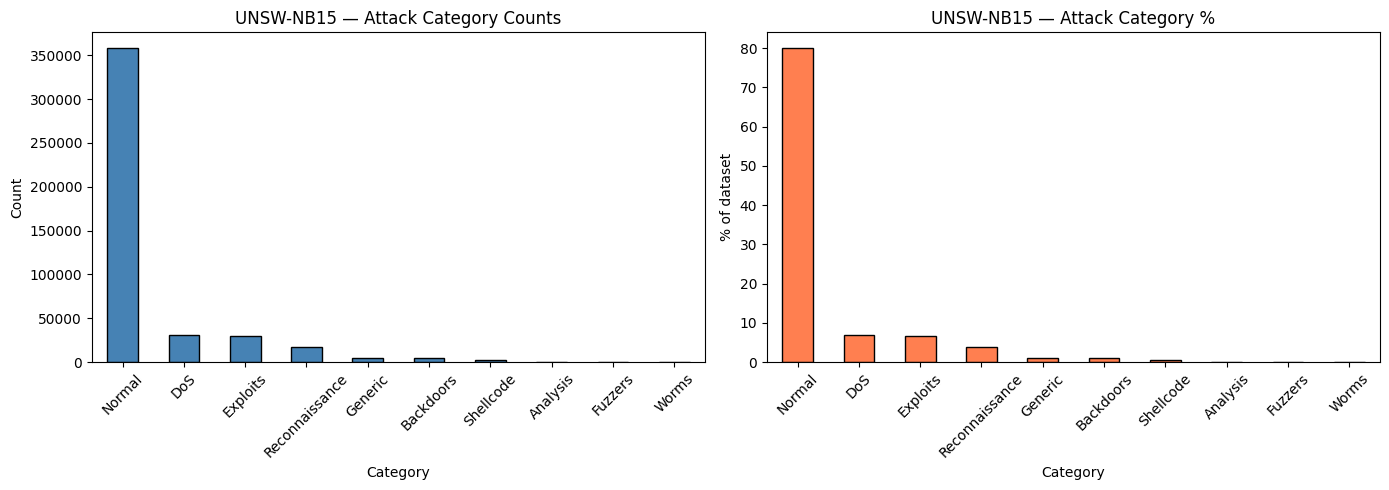

In [15]:
# Class label distribution
cat_counts = df['attack_cat'].value_counts()
pcts = (cat_counts / len(df) * 100).round(2)

print("Attack category counts:")
print(cat_counts)
print("\nPercentages:")
print(pcts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
cat_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('UNSW-NB15 — Attack Category Counts')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Percentage plot
pcts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('UNSW-NB15 — Attack Category %')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('% of dataset')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../data/eda_unswnb15_label_dist.png", dpi=150)
plt.show()

In [16]:
# Constant features (zero variance)
constant_features = [col for col in numeric_cols if df[col].nunique() <= 1]

print(f"Constant features ({len(constant_features)}):")
for col in constant_features:
    print(f"  '{col}'  —  value: {df[col].unique()}")

Constant features (9):
  'Bwd PSH Flags'  —  value: [0]
  'Fwd URG Flags'  —  value: [0]
  'Bwd URG Flags'  —  value: [0]
  'URG Flag Count'  —  value: [0]
  'CWR Flag Count'  —  value: [0]
  'ECE Flag Count'  —  value: [0]
  'Fwd Bytes/Bulk Avg'  —  value: [0]
  'Fwd Packet/Bulk Avg'  —  value: [0]
  'Fwd Bulk Rate Avg'  —  value: [0]


In [17]:
# Duplicate rows
n_dupes = df.duplicated().sum()
pct_dupes = (n_dupes / len(df) * 100).round(2)

print(f"Duplicate rows: {n_dupes} ({pct_dupes}%)")

if n_dupes > 0:
    print("\nSample of duplicates:")
    display(df[df.duplicated(keep=False)].head(10))

Duplicate rows: 141742 (31.64%)

Sample of duplicates:


,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,attack_cat
354,183,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,21857.923497,61.000000,99.594177,176.0,3.0,0.0,0.0,0.0,0.0,0.0,7.0,3.5,0.707107,4.0,3.0,0,0,0,0,32,96,5464.480874,16393.442623,0.0,0.0,0.0,0.000000,0.0,2,0,0,0,4,0,0,0,3.0,0.00,0.0,0.0,0,0,0,0,0,0,0,0,0,0,5792,10136,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal
1606,817,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,4895.960832,272.333333,461.307201,805.0,4.0,0.0,0.0,0.0,0.0,0.0,12.0,6.0,2.828427,8.0,4.0,0,0,0,0,32,96,1223.990208,3671.970624,0.0,0.0,0.0,0.000000,0.0,2,0,0,0,4,0,0,0,3.0,0.00,0.0,0.0,0,0,0,0,0,0,0,0,0,0,5792,10136,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal
3126,315,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,9523.809524,157.500000,219.910209,313.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.000000,2.0,2.0,0,0,0,0,32,64,3174.603175,6349.206349,0.0,0.0,0.0,0.000000,0.0,1,0,0,0,3,0,0,0,2.0,0.00,0.0,0.0,0,0,0,0,0,0,0,0,0,0,14480,14480,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal
3127,319,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,9404.388715,159.500000,222.738636,317.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.000000,2.0,2.0,0,0,0,0,32,64,3134.796238,6269.592476,0.0,0.0,0.0,0.000000,0.0,1,0,0,0,3,0,0,0,2.0,0.00,0.0,0.0,0,0,0,0,0,0,0,0,0,0,10136,10136,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal
3129,332,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,9036.144578,166.000000,227.688384,327.0,5.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,0.000000,5.0,5.0,0,0,0,0,32,64,3012.048193,6024.096386,0.0,0.0,0.0,0.000000,0.0,1,0,0,0,3,0,0,0,2.0,0.00,0.0,0.0,0,0,0,0,0,0,0,0,0,0,10136,5792,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal
3130,8,2,0,112.0,0.0,56.0,56.0,56.0,0.0,0.0,0.0,0.0,0.0,1.400000e+07,250000.000000,8.000000,0.000000,8.0,8.0,8.0,8.0,0.0,8.0,8.0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0,16,0,250000.000000,0.000000,56.0,56.0,56.0,0.000000,0.0,0,0,0,0,0,0,0,0,0.0,84.00,56.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,Reconnaissance
3131,1089,2,2,74.0,106.0,37.0,37.0,37.0,0.0,53.0,53.0,53.0,0.0,1.652893e+05,3673.094582,363.000000,611.414753,1069.0,9.0,11.0,11.0,0.0,11.0,11.0,9.0,9.0,0.000000,9.0,9.0,0,0,0,0,16,16,1836.547291,1836.547291,37.0,53.0,43.4,8.763561,76.8,0,0,0,0,0,0,0,0,1.0,54.25,37.0,53.0,0,0,0,180,4,165289,0,0,0,0,0,0,1,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal
3133,129,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,23255.813953,64.500000,86.974134,126.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.000000,3.0,3.0,0,0,0,0,32,64,7751.937984,15503.875969,0.0,0.0,0.0,0.000000,0.0,1,0,0,0,3,0,0,0,2.0,0.00,0.0,0.0,0,0,0,0,0,0,0,0,0,0,14480,14480,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal
3134,125,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,24000.000000,62.50000

In [18]:
# Infinite values
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_cols = inf_counts[inf_counts > 0]

print(f"Columns with infinite values ({len(inf_cols)}):")
print(inf_cols if len(inf_cols) else "None")

Columns with infinite values (0):
None
